# Orientation bias from voxel-grid discretization

Quantifies the artefact introduced by marching-cubes surface extraction on a regular voxel grid: how much do the measured anisotropy index β and principal-axis orientation vary as the same abstract triaxial ellipsoid is presented at different orientations relative to the grid?

**Shape**: triaxial ellipsoid with semi-axes A=10, B=6, C=4 (dimensionless — no physical unit). The ellipsoid is rotated through 12 orientations (0°–165° in 15° steps) **in the axis-0/axis-1 plane** (i.e. around array axis-2, the pykarambola z-axis), and discretized at four voxel sizes expressed as fractions of A.

**All six rank-2 Minkowski tensors** are evaluated:
- Position tensors: `w020` (solid moment), `w120` (surface moment), `w220` (mean-curvature weighted), `w320` (Gauss-curvature weighted)
- Normal tensors: `w102` (normal distribution), `w202` (curvature-weighted normal distribution)

For each tensor the anisotropy index β = λ_min/λ_max and the principal-axis orientation error (angle between the recovered long-axis eigenvector and the true rotation axis) are measured.

**Numerical reference values** are computed by integrating the Minkowski tensor integrands over the parametric ellipsoid surface x(u,v) = (A cos u sin v, B sin u sin v, C cos v).

Also demonstrates that scalar Minkowski functionals (w000–w300) converge asymptotically with resolution without orientation-dependent bias, whereas rank-2 tensor β values carry an orientation-dependent spread that persists at coarse resolutions.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import platform
import warnings
import trimesh as tm
from skimage.measure import marching_cubes

import pykarambola

print(f'pykarambola : {pykarambola.__version__}')
print(f'Python      : {platform.python_version()}')
print(f'OS          : {platform.system()} {platform.release()}')

pykarambola : 0.5.0
Python      : 3.11.13
OS          : Darwin 24.6.0


In [2]:
RESULTS_DIR = os.path.join(os.getcwd(), 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

# Ellipsoid semi-axes — purely dimensionless; A is the reference length
A, B, C = 10.0, 6.0, 4.0          # long, medium, short

# Voxel sizes as fractions of A  →  voxels-per-A = int(A/vox)
VOX_FRACS   = [1/40, 1/20, 1/10, 1/5]    # 40, 20, 10, 5 voxels per A
VOXEL_SIZES = [A * f for f in VOX_FRACS]  # [0.25, 0.50, 1.00, 2.00]
VOX_LABELS  = [f'A/{int(1/f):d} ({int(1/f):d} vox)' for f in VOX_FRACS]

# Rotation angles: 12 orientations in the axis-0/axis-1 plane (around axis-2 = pykarambola z)
ANGLES = np.arange(0, 180, 15)

# Fine-reference voxel size (100 voxels per A)
FINE_VOX = A / 100.0

# All six rank-2 Minkowski tensors
RANK2 = ['w020', 'w120', 'w220', 'w320', 'w102', 'w202']

# Which eigenvector (eigvals sorted ascending) is the long-axis direction?
#   Position tensors (w{n}20): lambda_max  ->  long axis  ->  eigvecs[:, 2]
#   Normal   tensors (w{n}02): lambda_min  ->  long axis  ->  eigvecs[:, 0]
LONG_IDX = {'w020': 2, 'w120': 2, 'w220': 2, 'w320': 2, 'w102': 0, 'w202': 0}

BASE_FONT     = 16
TENSOR_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
VOX_COLORS    = ['#2166ac', '#4dac26', '#d01c8b', '#e66101']

print(f'Ellipsoid semi-axes : A={A}, B={B}, C={C}  (dimensionless)')
print(f'Voxel sizes         : {VOXEL_SIZES}  (fractions of A)')
print(f'Voxels per A        : {[int(A/v) for v in VOXEL_SIZES]}')
print(f'Rotation plane      : axis-0 / axis-1  (rotation axis = array axis-2 = pykarambola z)')

Ellipsoid semi-axes : A=10.0, B=6.0, C=4.0  (dimensionless)
Voxel sizes         : [0.25, 0.5, 1.0, 2.0]  (fractions of A)
Voxels per A        : [40, 20, 10, 5]
Rotation plane      : axis-0 / axis-1  (rotation axis = array axis-2 = pykarambola z)


In [3]:
# ── Analytical reference β for all six rank-2 tensors ────────────────────────
#
# w020 (solid moment): W_ii = (4pi/15) * li^3 * lj * lk  (exact formula)
#   -> beta = (lz/lx)^2 = (C/A)^2
def _beta_w020(lx, ly, lz):
    ev = np.sort([(4*np.pi/15) * li**3 * lj * lk
                  for li, lj, lk in [(lx, ly, lz), (ly, lx, lz), (lz, lx, ly)]])
    return float(ev[0] / ev[2])


# Surface tensors: numerical integration over parametric ellipsoid surface
#   x(u,v) = (lx cos(u)sin(v),  ly sin(u)sin(v),  lz cos(v))
def _surface_betas(lx, ly, lz, N_u=400, N_v=200):
    u = np.linspace(0, 2*np.pi, N_u, endpoint=False)
    v = np.linspace(1e-5, np.pi - 1e-5, N_v)
    U, V = np.meshgrid(u, v, indexing='ij')

    X = lx * np.cos(U) * np.sin(V)
    Y = ly * np.sin(U) * np.sin(V)
    Z = lz * np.cos(V)

    # Unnormalized outward normal: N = r_u x r_v = sin(V) * p
    # p = ( ly*lz cos(u)sin(v),  lx*lz sin(u)sin(v),  lx*ly cos(v) )
    Px = ly * lz * np.cos(U) * np.sin(V)
    Py = lx * lz * np.sin(U) * np.sin(V)
    Pz = lx * ly * np.cos(V)
    Pm = np.sqrt(Px**2 + Py**2 + Pz**2)
    nx, ny, nz = Px/Pm, Py/Pm, Pz/Pm

    # Area weight: dA = sin(V) * |p| * du * dv
    w = np.sin(V) * Pm * (u[1]-u[0]) * (v[1]-v[0])

    # Second fundamental form (M=0 analytically):
    #   L     = r_uu . nhat = -lx*ly*lz * sin^2(v) / |p|
    #   N_sff = r_vv . nhat = -lx*ly*lz / |p|
    L  = -lx * ly * lz * np.sin(V)**2 / Pm
    Ns = -lx * ly * lz / Pm

    # First fundamental form
    E = lx**2*np.sin(U)**2*np.sin(V)**2 + ly**2*np.cos(U)**2*np.sin(V)**2
    F = np.sin(U)*np.cos(U)*np.sin(V)*np.cos(V)*(ly**2 - lx**2)
    G = lx**2*np.cos(U)**2*np.cos(V)**2 + ly**2*np.sin(U)**2*np.cos(V)**2 + lz**2*np.sin(V)**2
    EGF2 = E*G - F**2

    # Mean curvature H (positive for convex shape): negate formula result
    # (the formula gives H < 0 for outward-pointing normal on convex surfaces)
    H = -((E*Ns + G*L) / (2*EGF2))

    # Gaussian curvature K = L*N_sff / (EG-F^2)  (positive for convex shapes)
    K = L*Ns / EGF2

    def _T(ax, ay, az, wt):
        a  = [ax.ravel(), ay.ravel(), az.ravel()]
        wr = wt.ravel()
        T  = np.zeros((3, 3))
        for i in range(3):
            for j in range(3):
                T[i, j] = np.dot(a[i] * wr, a[j])
        return T

    def _b(T):
        ev = np.sort(np.linalg.eigvalsh(T))
        return float(ev[0] / ev[2])

    return {
        'w120': _b(_T(X, Y, Z, w)),
        'w102': _b(_T(nx, ny, nz, w)),
        'w220': _b(_T(X, Y, Z, H * w)),
        'w320': _b(_T(X, Y, Z, K * w)),
        'w202': _b(_T(nx, ny, nz, H * w)),
    }


print('Computing analytical reference beta values ...')
ANA_BETA = {'w020': _beta_w020(A, B, C)}
ANA_BETA.update(_surface_betas(A, B, C))

print('\nAnalytical reference beta:')
for name in RANK2:
    print(f'  {name}: {ANA_BETA[name]:.6f}')

Computing analytical reference beta values ...

Analytical reference beta:
  w020: 0.160000
  w120: 0.222127
  w220: 0.114707
  w320: 0.053367
  w102: 0.227571
  w202: 0.469478


In [4]:
def make_ellipsoid_mask(lx, ly, lz, voxel_size, angle_deg, pad=4):
    """Binary mask of a triaxial ellipsoid rotated angle_deg in the axis-0/axis-1 plane."""
    theta = np.deg2rad(angle_deg)
    n0 = int(np.ceil(max(lx, ly) / voxel_size)) + pad
    n1 = int(np.ceil(max(lx, ly) / voxel_size)) + pad
    n2 = int(np.ceil(lz           / voxel_size)) + pad
    X0, X1, X2 = np.meshgrid(
        np.arange(-n0, n0+1) * voxel_size,
        np.arange(-n1, n1+1) * voxel_size,
        np.arange(-n2, n2+1) * voxel_size,
        indexing='ij',
    )
    # Inverse rotation: test each voxel in the body frame
    X0r =  X0 * np.cos(theta) + X1 * np.sin(theta)
    X1r = -X0 * np.sin(theta) + X1 * np.cos(theta)
    return ((X0r/lx)**2 + (X1r/ly)**2 + (X2/lz)**2 <= 1.0).astype(np.uint8)


def measure_all(mask, voxel_size, angle_deg):
    """Return β and long-axis eigenvector error for all 6 rank-2 tensors + 4 scalars."""
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        r = pykarambola.minkowski_tensors_from_label_image(
            mask, spacing=(voxel_size, voxel_size, voxel_size)
        )[1]

    theta     = np.deg2rad(angle_deg)
    true_axis = np.array([np.cos(theta), np.sin(theta), 0.0])

    out = {}
    for name in RANK2:
        ev   = r.get(f'{name}_eigvals')
        evec = r.get(f'{name}_eigvecs')
        if ev is None:
            out[f'{name}_beta'] = out[f'{name}_aerr'] = np.nan
            continue
        out[f'{name}_beta'] = float(ev[0] / ev[2])
        la_vec = evec[:, LONG_IDX[name]]
        out[f'{name}_aerr'] = float(np.degrees(
            np.arccos(np.clip(abs(la_vec @ true_axis), 0.0, 1.0))
        ))

    for sc in ('w000', 'w100', 'w200', 'w300'):
        out[sc] = float(r.get(sc, np.nan))
    return out


print('Helpers defined.')

Helpers defined.


In [5]:
# ── Mesh visualizations: 4 orientations in 4 colours ─────────────────────────
# Voxel size A/10 (10 voxels per A) — coarse enough to show staircase
# artefacts while keeping the shape recognisable.  Rotation is in the
# axis-0/axis-1 plane; meshes are spread along the x-axis for clarity.
VIZ_VOX    = A / 10.0
VIZ_ANGLES = [0, 45, 90, 135]
VIZ_RGBA   = [
    [230, 159,   0, 220],   # orange
    [  0, 158, 115, 220],   # teal
    [ 86, 180, 233, 220],   # sky blue
    [204, 121, 167, 220],   # rose
]

OFFSET = 2.6 * A
axis_obj = tm.creation.axis(axis_length=A * 0.7, axis_radius=A * 0.035)
scene_parts = [axis_obj]

for k, (ang, rgba) in enumerate(zip(VIZ_ANGLES, VIZ_RGBA)):
    m_mask = make_ellipsoid_mask(A, B, C, VIZ_VOX, ang)
    verts, faces, _, _ = marching_cubes(
        m_mask.astype(float), level=0.5,
        spacing=(VIZ_VOX, VIZ_VOX, VIZ_VOX),
    )
    verts -= verts.mean(axis=0)
    verts[:, 0] += k * OFFSET
    mesh = tm.Trimesh(vertices=verts, faces=faces, process=False)
    mesh.visual.face_colors = rgba
    scene_parts.append(mesh)
    print(f'  {ang:3d}deg: {len(faces):,} faces')

print('\nMesh layout (left -> right): 0deg, 45deg, 90deg, 135deg')
print('Colours: orange | teal | sky-blue | rose')
print('Rotation is in the axis-0/axis-1 plane (long axis sweeps x-y; z axis is fixed)')
tm.Scene(scene_parts).show()

    0deg: 1,512 faces
   45deg: 1,584 faces
   90deg: 1,512 faces
  135deg: 1,584 faces

Mesh layout (left -> right): 0deg, 45deg, 90deg, 135deg
Colours: orange | teal | sky-blue | rose
Rotation is in the axis-0/axis-1 plane (long axis sweeps x-y; z axis is fixed)


In [6]:
# ── Fine-resolution reference measurements ───────────────────────────────────
# vox = A/100  ->  100 voxels per semi-axis A  ~  converged limit for pykarambola
print(f'Computing fine-resolution reference  (vox = A/100 = {FINE_VOX}) ...')
mask_fine = make_ellipsoid_mask(A, B, C, FINE_VOX, angle_deg=0)
FINE_VALS = measure_all(mask_fine, FINE_VOX, angle_deg=0)

# Fine-resolution beta: used as the "true" reference for orientation-bias analysis.
# ANA_BETA (from smooth surface integration) matches well for w020 and w120,
# but differs more for w102/w202 (discrete vs. smooth face normals) and
# w220/w320 (dihedral-angle / angle-deficit approximations at finite resolution).
FINE_BETA = {name: FINE_VALS[f'{name}_beta'] for name in RANK2}

print('\nbeta: fine-resolution vs. analytical reference')
print(f"  {'tensor':<8}  {'fine-res':>10}  {'analytical':>10}  {'diff %':>8}")
for name in RANK2:
    fv  = FINE_BETA[name]
    av  = ANA_BETA[name]
    pct = 100 * abs(fv - av) / abs(av)
    match = '(good)' if pct < 2.0 else ''
    print(f'  {name:<8}  {fv:10.6f}  {av:10.6f}  {pct:8.3f}%  {match}')

FINE_SCALARS = {sc: FINE_VALS[sc] for sc in ('w000', 'w100', 'w200', 'w300')}
print('\nFine-resolution scalar references:')
for sc, val in FINE_SCALARS.items():
    print(f'  {sc} = {val:.6f}')

Computing fine-resolution reference  (vox = A/100 = 0.1) ...

beta: fine-resolution vs. analytical reference
  tensor      fine-res  analytical    diff %
  w020        0.159836    0.160000     0.102%  (good)
  w120        0.220919    0.222127     0.544%  (good)
  w220        0.154820    0.114707    34.970%  
  w320        0.103546    0.053367    94.028%  
  w102        0.322079    0.227571    41.529%  
  w202        0.556597    0.469478    18.556%  

Fine-resolution scalar references:
  w000 = 1004.682500
  w100 = 195.453457
  w200 = 31.641346
  w300 = 4.188790


In [7]:
# ── Scalar convergence vs. resolution (angle = 0) ────────────────────────────
# Demonstrates asymptotic convergence of scalar Minkowski functionals with no
# orientation-dependent component.  Contrast with tensor beta spread in the
# final figure.
vox_for_conv = sorted([A/n for n in (5, 8, 10, 15, 20, 30, 40)], reverse=True)

conv_rows = []
for vox in vox_for_conv:
    mask = make_ellipsoid_mask(A, B, C, vox, angle_deg=0)
    vals = measure_all(mask, vox, angle_deg=0)
    row  = {'vox': vox, 'vox_per_A': round(A/vox, 1)}
    for sc in ('w000', 'w100', 'w200', 'w300'):
        ref = FINE_SCALARS[sc]
        row[f'{sc}_err'] = 100*abs(vals[sc] - ref) / abs(ref) if abs(ref) > 1e-12 else np.nan
    conv_rows.append(row)
    print(f'  vox=A/{int(A/vox):d}  done')

DF_CONV = pd.DataFrame(conv_rows)
print('\nScalar relative errors (%) vs. voxels per A:')
cols = ['vox_per_A'] + [f'{sc}_err' for sc in ('w000','w100','w200','w300')]
print(DF_CONV[cols].to_string(index=False, float_format='{:.3f}'.format))

  vox=A/5  done
  vox=A/8  done
  vox=A/10  done
  vox=A/15  done
  vox=A/20  done
  vox=A/30  done
  vox=A/40  done

Scalar relative errors (%) vs. voxels per A:
 vox_per_A  w000_err  w100_err  w200_err  w300_err
     5.000    15.728     7.634     0.216     0.000
     8.000     2.054     2.103     0.842     0.000
    10.000     3.502     0.743     2.469     0.000
    15.000     1.769     0.560     1.368     0.000
    20.000     0.564     0.457     0.818     0.000
    30.000     0.502     0.666     0.099     0.000
    40.000     0.219     0.196     0.412     0.000


In [8]:
# ── Main sweep: all 6 rank-2 tensors × 4 voxel sizes × 12 angles ─────────────
records = []
for vox in VOXEL_SIZES:
    n_vox = int(A / vox)
    for ang in ANGLES:
        mask = make_ellipsoid_mask(A, B, C, vox, ang)
        vals = measure_all(mask, vox, ang)
        rec  = {'voxel_size': vox, 'n_vox_A': n_vox, 'angle_deg': float(ang)}
        rec.update(vals)
        records.append(rec)
    print(f'  vox=A/{n_vox:d}  done')

DF = pd.DataFrame(records)

# ── Summary table ─────────────────────────────────────────────────────────────
col_hdrs = [f'A/{int(A/v)}' for v in VOXEL_SIZES]
header   = f"{'tensor':<8}" + ''.join(f'  {h:<10}' for h in col_hdrs)
sep      = '-' * len(header)

# Reference: fine-resolution beta (converged limit for pykarambola's discrete operators)
print('\nbeta orientation spread  (beta_max - beta_min across 12 angles, % of fine-res beta)')
print(header); print(sep)
for name in RANK2:
    ref = FINE_BETA[name]
    row = f'{name:<8}'
    for vox in VOXEL_SIZES:
        sub = DF[DF['voxel_size'] == vox]
        pct = 100*(sub[f'{name}_beta'].max() - sub[f'{name}_beta'].min()) / ref
        row += f'  {pct:5.1f}%    '
    print(row)

print('\nmax long-axis eigenvector error (degrees)')
print(header); print(sep)
for name in RANK2:
    row = f'{name:<8}'
    for vox in VOXEL_SIZES:
        sub = DF[DF['voxel_size'] == vox]
        row += f'  {sub[f"{name}_aerr"].max():5.2f} deg  '
    print(row)

  vox=A/40  done
  vox=A/20  done
  vox=A/10  done
  vox=A/5  done

beta orientation spread  (beta_max - beta_min across 12 angles, % of fine-res beta)
tensor    A/40        A/20        A/10        A/5       
--------------------------------------------------------
w020        0.4%        0.7%        4.6%        7.2%    
w120        0.8%        1.7%        4.8%        7.5%    
w220        2.5%        2.5%        5.9%       14.0%    
w320        3.9%        3.9%        8.3%       40.9%    
w102        0.3%        3.4%        9.0%        9.9%    
w202        1.3%        1.1%        4.5%       12.5%    

max long-axis eigenvector error (degrees)
tensor    A/40        A/20        A/10        A/5       
--------------------------------------------------------
w020       0.09 deg     0.09 deg     1.16 deg     3.99 deg  
w120       0.09 deg     0.31 deg     1.16 deg     3.52 deg  
w220       0.05 deg     0.52 deg     1.69 deg     3.04 deg  
w320       0.08 deg     0.66 deg     2.49 deg     2.

Saved -> /Users/yk/Desktop/pykarambola_m1/pykarambola/paper/notebooks/results/orientation_bias_beta.pdf


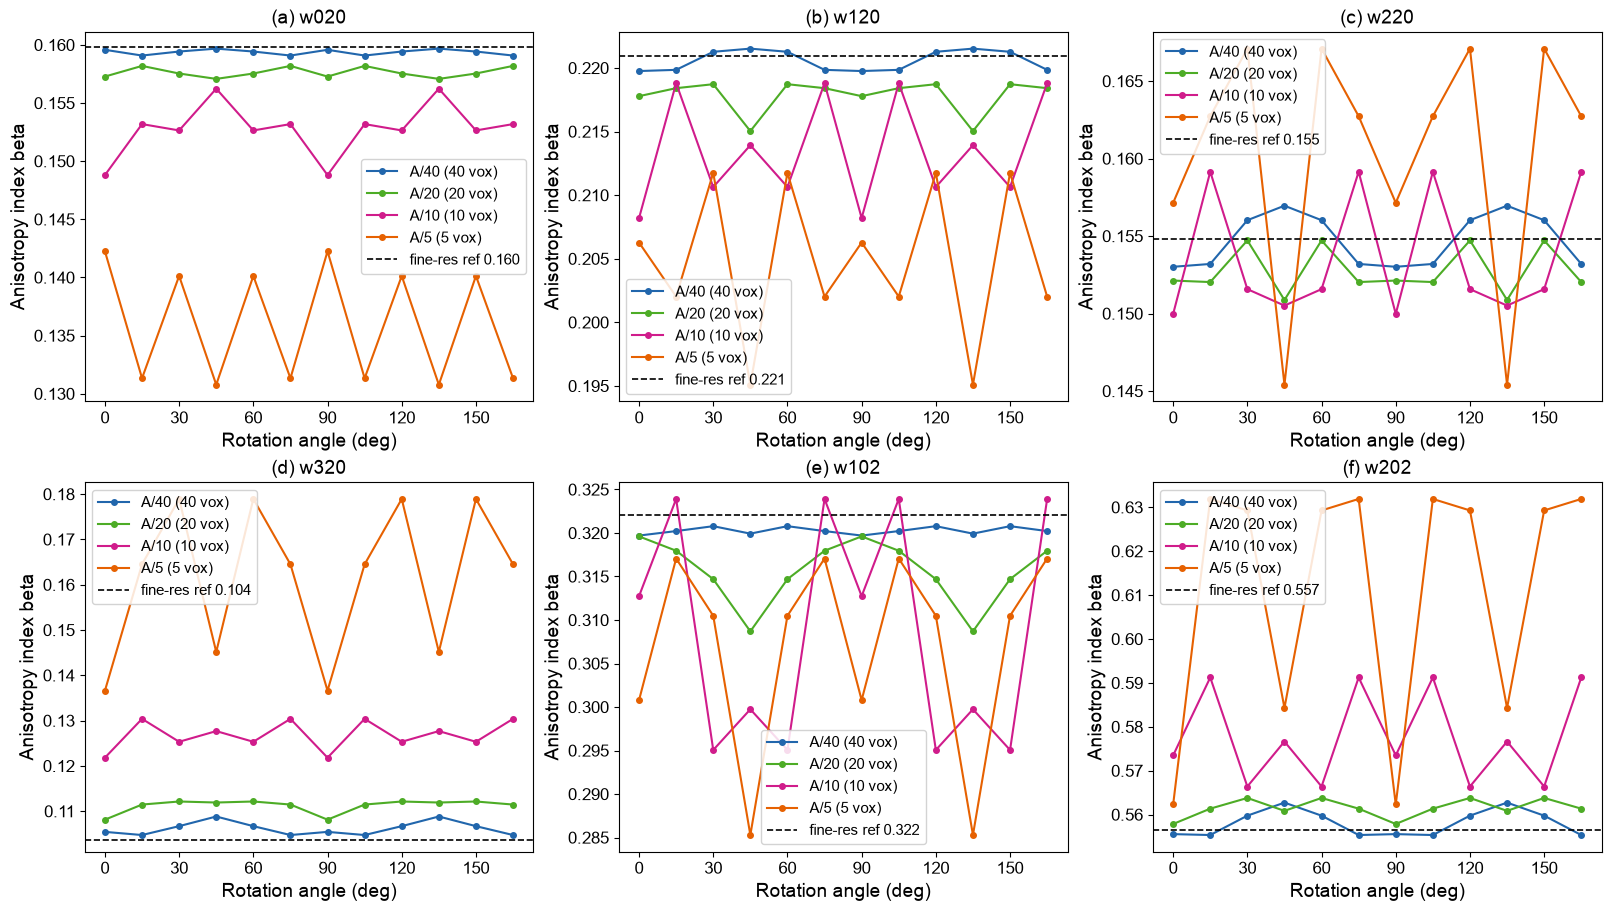

In [9]:
# ── Figure: beta vs. rotation angle for all six rank-2 tensors ───────────────
plt.rcParams['font.family'] = 'Arial'
plt.rcParams.update({
    'font.size':       BASE_FONT,
    'axes.titlesize':  BASE_FONT - 2,
    'axes.labelsize':  BASE_FONT - 2,
    'xtick.labelsize': BASE_FONT - 4,
    'ytick.labelsize': BASE_FONT - 4,
    'legend.fontsize': BASE_FONT - 5,
})

fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)

for idx, name in enumerate(RANK2):
    ax = axes.flat[idx]
    rv = FINE_BETA[name]   # fine-resolution reference
    for vox, col, lbl in zip(VOXEL_SIZES, VOX_COLORS, VOX_LABELS):
        sub = DF[DF['voxel_size'] == vox].sort_values('angle_deg')
        ax.plot(sub['angle_deg'], sub[f'{name}_beta'],
                'o-', ms=4, lw=1.5, color=col, label=lbl)
    ax.axhline(rv, color='k', ls='--', lw=1.2, label=f'fine-res ref {rv:.3f}')
    ax.set_title(f'({chr(97+idx)}) {name}')
    ax.set_xlabel('Rotation angle (deg)')
    ax.set_ylabel('Anisotropy index beta')
    ax.set_xticks(ANGLES[::2])
    ax.legend(loc='best', framealpha=0.85)

save_path = os.path.join(RESULTS_DIR, 'orientation_bias_beta.pdf')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved -> {save_path}')
plt.show()

Saved -> /Users/yk/Desktop/pykarambola_m1/pykarambola/paper/notebooks/results/orientation_bias_eigvec.pdf


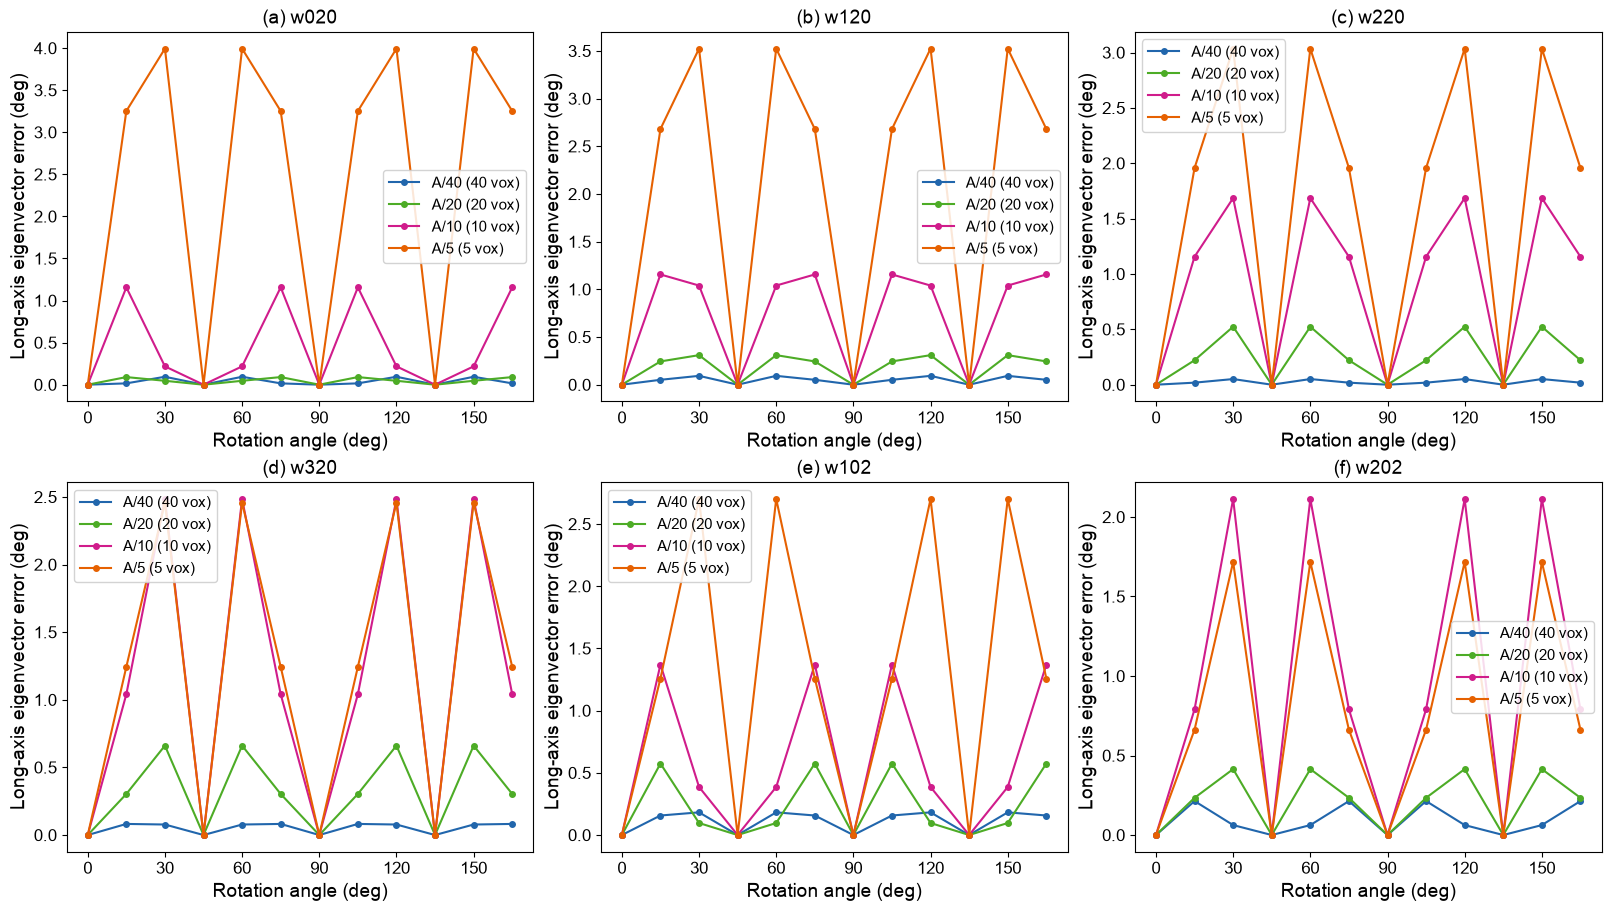

In [10]:
# ── Figure: long-axis eigenvector error vs. rotation angle ───────────────────
fig2, axes2 = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)

for idx, name in enumerate(RANK2):
    ax = axes2.flat[idx]
    for vox, col, lbl in zip(VOXEL_SIZES, VOX_COLORS, VOX_LABELS):
        sub = DF[DF['voxel_size'] == vox].sort_values('angle_deg')
        ax.plot(sub['angle_deg'], sub[f'{name}_aerr'],
                'o-', ms=4, lw=1.5, color=col, label=lbl)
    ax.set_title(f'({chr(97+idx)}) {name}')
    ax.set_xlabel('Rotation angle (deg)')
    ax.set_ylabel('Long-axis eigenvector error (deg)')
    ax.set_xticks(ANGLES[::2])
    ax.legend(loc='best', framealpha=0.85)

save_path = os.path.join(RESULTS_DIR, 'orientation_bias_eigvec.pdf')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved -> {save_path}')
plt.show()

Saved -> /Users/yk/Desktop/pykarambola_m1/pykarambola/paper/notebooks/results/orientation_bias.pdf


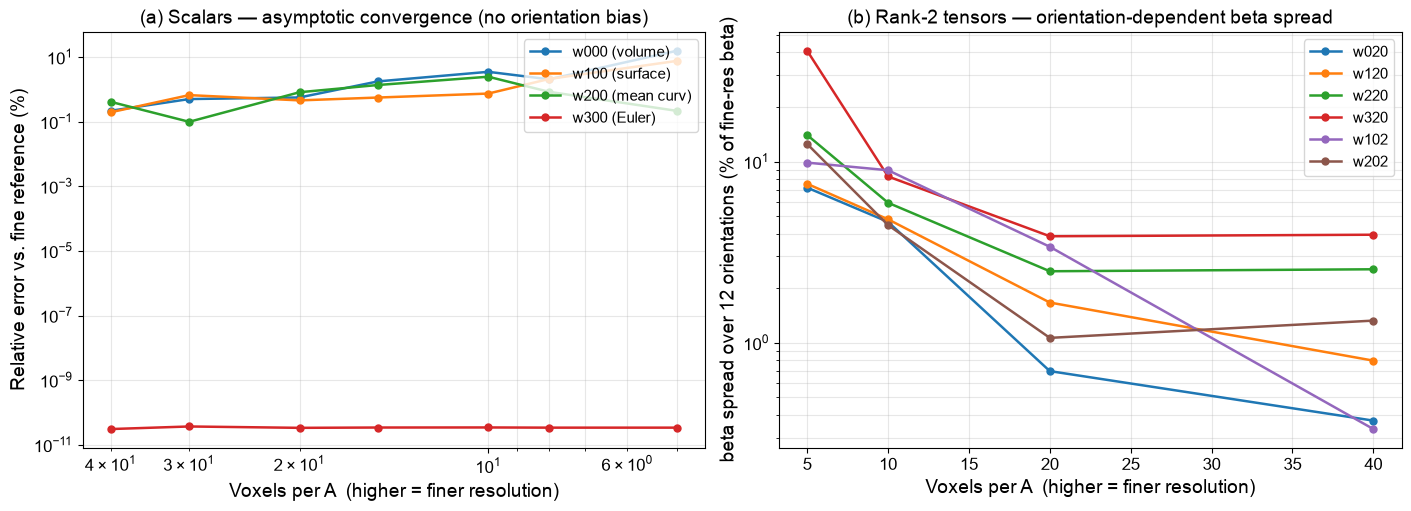

In [11]:
# ── Figure: scalars converge; tensors carry orientation-dependent spread ──────
# Left panel:  relative error of each scalar at angle=0 vs. resolution
#              -> errors decrease monotonically, no orientation dependence
# Right panel: tensor beta orientation spread (max-min over 12 angles,
#              % of fine-resolution beta) vs. resolution
fig3, (ax_s, ax_t) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Panel A — scalar convergence
SC_LABELS = {'w000': 'w000 (volume)', 'w100': 'w100 (surface)',
             'w200': 'w200 (mean curv)', 'w300': 'w300 (Euler)'}
SC_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for sc, col in zip(('w000','w100','w200','w300'), SC_COLORS):
    ax_s.loglog(DF_CONV['vox_per_A'], DF_CONV[f'{sc}_err'],
                'o-', ms=5, lw=1.8, color=col, label=SC_LABELS[sc])
ax_s.set_xlabel('Voxels per A  (higher = finer resolution)')
ax_s.set_ylabel('Relative error vs. fine reference (%)')
ax_s.set_title('(a) Scalars — asymptotic convergence (no orientation bias)')
ax_s.legend(fontsize=BASE_FONT-5, loc='upper right')
ax_s.grid(True, which='both', alpha=0.3)
ax_s.invert_xaxis()

# Panel B — tensor beta orientation spread
for name, col in zip(RANK2, TENSOR_COLORS):
    ref     = FINE_BETA[name]
    spreads = []
    vpas    = []
    for vox in VOXEL_SIZES:
        sub = DF[DF['voxel_size'] == vox]
        bv  = sub[f'{name}_beta']
        spreads.append(100*(bv.max() - bv.min()) / ref)
        vpas.append(int(A / vox))
    ax_t.semilogy(vpas, spreads, 'o-', ms=5, lw=1.8, color=col, label=name)
ax_t.set_xlabel('Voxels per A  (higher = finer resolution)')
ax_t.set_ylabel('beta spread over 12 orientations (% of fine-res beta)')
ax_t.set_title('(b) Rank-2 tensors — orientation-dependent beta spread')
ax_t.legend(fontsize=BASE_FONT-5, loc='upper right')
ax_t.grid(True, which='both', alpha=0.3)

save_path = os.path.join(RESULTS_DIR, 'orientation_bias.pdf')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved -> {save_path}')
plt.show()